In [37]:
import copy
import numpy as np
import pandas as pd
import torch

from torch import nn
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

print("torch :", torch.__version__)
print("cuda  :", torch.cuda.is_available())
print("device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu")

torch : 2.13.0+cu132
cuda  : True
device: NVIDIA GeForce RTX 4090 Laptop GPU


In [38]:
# A batch is the number of training rows given to the autoencoder before it updates its weights.
# The bottleneck is the narrowest layer of the autoencoder.
# A very small bottleneck may lose important normal information.
# A very large bottleneck may allow the model to copy abnormal data too easily.
# The best size must therefore be determined experimentally.

batch = 128
bottleneck = 4

# The shape and training of the model, held constant so that any difference
# in the results comes from batch and bottleneck and nothing else.
hidden = 64
epochs = 50
learning_rate = 0.001

# The same model trained five times from different random starting weights.
# The average is the result.
seeds = [0, 1, 2, 3, 4]

# This reserves 20% of the normal recordings for validation.
val_fraction = 0.2

# stop training if the validation loss has not improved for this many epochs
patience = 10

device = "cuda" if torch.cuda.is_available() else "cpu"

print("batch:", batch, " bottleneck:", bottleneck, " device:", device)

batch: 128  bottleneck: 4  device: cuda


In [39]:
# The 94 features built in feature_engineering.ipynb, plus the run number.

train_data = pd.read_csv(r"C:\shared\LSBU\ablation-study-with-developed-hypertuned-models-for-anomaly-detection-in-hrc-robotics\train_dataset.csv")

print("rows   :", len(train_data))
print("columns:", train_data.shape[1])

rows   : 1556661
columns: 95


In [40]:
# The 80 labelled recording test data.

test_data = pd.read_csv(r"C:\shared\LSBU\ablation-study-with-developed-hypertuned-models-for-anomaly-detection-in-hrc-robotics\test_dataset.csv")

print("rows   :", len(test_data))
print("columns:", test_data.shape[1])
print()
print(test_data["anomaly_type"].value_counts())

rows   : 246151
columns: 97

anomaly_type
long_wait        47979
scale_speed      32804
push             31117
tcp_wrench       31062
change_weight    28978
force_stop       28438
outside_box      23499
drop_object      22274
Name: count, dtype: int64


In [41]:
# Every column except the run number is a feature the model will see.

feature_names = list(train_data.columns.drop("run_number"))

print("features:", len(feature_names))

features: 94


In [42]:
# Split the dataset by complete robot recordings rather than individual rows.
# At 100 Hz, neighbouring rows are nearly identical. A row-level split could
# place almost identical readings in fitting and validation.

# Get each unique run number once and arrange the numbers in order.
all_runs = sorted(train_data["run_number"].unique())

# Randomly assign 80% of complete runs to fitting and 20% to validation.
# val_fraction sets the validation proportion. The parameter is called
# test_size because that is sklearn's generic name for the second group.
fit_runs, val_runs = train_test_split(
    all_runs,
    test_size=val_fraction,
    random_state=42
)

# Keep rows whose run_number appears in the existing fit_runs list.
# The @ tells Pandas that fit_runs is a Python variable outside the DataFrame.
fit_rows = train_data.query("run_number in @fit_runs")

# The same for the runs held back for validation.
val_rows = train_data.query("run_number in @val_runs")

# Display the number of complete runs and individual rows in each group.
print("fitting   :", len(fit_runs), "runs,", len(fit_rows), "rows")
print("validation:", len(val_runs), "runs,", len(val_rows), "rows")

fitting   : 488 runs, 1241647 rows
validation: 122 runs, 315014 rows


In [43]:
# scaling

scaler = StandardScaler()

# fit_transform LEARNS the mean and spread, then applies them. It is used on the
# fitting rows only. The other two get transform, which just applies what was
# already learned.
fit_scaled = scaler.fit_transform(fit_rows[feature_names])
val_scaled = scaler.transform(val_rows[feature_names])
test_scaled = scaler.transform(test_data[feature_names])

print("fit :", fit_scaled.shape)
print("val :", val_scaled.shape)
print("test:", test_scaled.shape)

fit : (1241647, 94)
val : (315014, 94)
test: (246151, 94)


In [44]:
# Copy the scaled data onto the GPU once, as 32-bit numbers. Keeping it there
# means training never has to fetch batches from main memory, which is what
# makes 60 training runs finish in hours.

fit_tensor = torch.tensor(fit_scaled, dtype=torch.float32, device=device)
val_tensor = torch.tensor(val_scaled, dtype=torch.float32, device=device)
test_tensor = torch.tensor(test_scaled, dtype=torch.float32, device=device)

# The labels stay on the CPU, because only scikit-learn reads them and it
# cannot see the GPU.
test_labels = test_data["label"].values
test_types = test_data["anomaly_type"].values

fault_names = sorted(test_data["anomaly_type"].unique())

print("fit :", fit_tensor.shape)
print("val :", val_tensor.shape)
print("test:", test_tensor.shape)
print("faults:", fault_names)

fit : torch.Size([1241647, 94])
val : torch.Size([315014, 94])
test: torch.Size([246151, 94])
faults: ['change_weight', 'drop_object', 'force_stop', 'long_wait', 'outside_box', 'push', 'scale_speed', 'tcp_wrench']


In [45]:
# The model

class Autoencoder(nn.Module):

    def __init__(self, n_features, hidden, bottleneck):

        super().__init__()

        # squeeze 94 numbers down to a few
        self.encoder = nn.Sequential(
            nn.Linear(n_features, hidden),
            nn.ReLU(),
            nn.Linear(hidden, bottleneck),
        )

        # build the 94 back up from those few
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_features),
        )

    # what happens when a reading is passed through the model
    def forward(self, x):
        squeezed = self.encoder(x)
        rebuilt = self.decoder(squeezed)
        return rebuilt


# just to look at the shape before training anything
print(Autoencoder(len(feature_names), hidden, bottleneck))

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=94, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=4, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=94, bias=True)
  )
)


In [46]:
# calculate one anomaly score for every row
# A larger reconstruction error means the row is less familiar to the model

def reconstruction_error(model, x):

    # put the model into evaluation mode because no training happens here
    model.eval()

    # do not calculate gradients because the model's weights will not be updated
    with torch.no_grad():

        # ask the autoencoder to reconstruct every input row.
        rebuilt = model(x)

        # calculate the squared difference between every original and rebuilt value.
        squared_error = (rebuilt - x) ** 2

         # average the feature errors within each row.
        # this leaves one reconstruction-error score for every row.
        per_row = squared_error.mean(dim=1)

    # back to the CPU as NumPy array because scikit-learn scores them there
    return per_row.cpu().numpy()

In [47]:
# Train one autoencoder from start to finish. The seed is the only thing that
# changes between the five runs; batch, bottleneck and the rest come from the
# settings cell at the top.

def train_one_model(seed):

    # start the random numbers from the same place, so the run is repeatable
    torch.manual_seed(seed)

    model = Autoencoder(len(feature_names), hidden, bottleneck).to(device)

    optimiser = torch.optim.Adam(model.parameters(), lr=learning_rate)
    loss_function = nn.MSELoss()

    n_rows = fit_tensor.shape[0]

    # the best validation loss seen so far, which epoch produced it, and a copy
    # of the weights from that epoch
    best_val = float("inf")
    best_epoch = 0
    best_weights = None

    # how many epochs in a row have gone by with no improvement
    waited = 0

    # validation loss after every epoch, kept so the curve can be plotted later
    val_curve = []

    for epoch in range(epochs):

        model.train()

        # create a list containing every training row number once, but mix their order.
        # example: [0, 1, 2, 3] could become [2, 0, 3, 1].
        order = torch.randperm(n_rows, device=device)

        # take the mixed row numbers in groups of the chosen batch size.
        # for example batch=128, start becomes 0, 128, 256, 384, and so on.
        for start in range(0, n_rows, batch):
        
            # take the next group of shuffled row numbers and collect those rows.
            # for example, if the numbers are [7, 2, 9], collect rows 7, 2 and 9.
            rows = fit_tensor[order[start:start + batch]]

            rebuilt = model(rows)
            loss = loss_function(rebuilt, rows)

            optimiser.zero_grad() # clear the previous step's gradients
            loss.backward() # calculates how every weight contributed to the reconstruction error.
            optimiser.step() # Adam uses those gradients and the learning rate to update the model’s weights.

        # measure on the 122 held-back recordings at the end of every epoch
        val_loss = float(reconstruction_error(model, val_tensor).mean())
        val_curve.append(val_loss)

        if val_loss < best_val:

            # save this validation loss because it is the lowest one seen so far.
            best_val = val_loss
            # remember which epoch produced the lowest validation loss.
            best_epoch = epoch + 1
            # save an independent copy of the model at this best epoch.
            best_weights = copy.deepcopy(model.state_dict())
            # improvement occurred, so restart the early-stopping counter.
            waited = 0

        else:
            # validation did not improve, so count another unsuccessful epoch.
            waited = waited + 1
        
        # display the validation loss after every 10 epochs.
        if (epoch + 1) % 10 == 0:
            print("      epoch", epoch + 1, "of", epochs, "  val loss", round(val_loss, 6))

        # stop when validation has not improved for the chosen number of epochs.
        if waited >= patience:
            print("      stopped early at epoch", epoch + 1, "- best was epoch", best_epoch)
            break

    # Put the best weights back. Without this the model keeps whatever the final
    # epoch happened to produce, which is not the model that was selected. Every
    # number measured afterwards would describe the wrong model.
    model.load_state_dict(best_weights)

    fit_loss = reconstruction_error(model, fit_tensor).mean() # this calculates the average reconstruction error across all fitting rows.

    return model, float(fit_loss), val_curve, best_epoch

In [48]:
# Train the same model five times, once per seed. From each one we keep two
# things: a note of how well it trained, and its score for every test row.

model_notes = []
model_errors = []

for seed in seeds:

    print("seed", seed)

    model, fit_loss, val_curve, best_epoch = train_one_model(seed)

    # The restored weights come from best_epoch, not from the last epoch, so the
    # validation loss to report is the best one - not val_curve[-1]. Taking the
    # last one would describe a model that was thrown away.
    val_loss = min(val_curve)

    # one anomaly score for each of the 246,151 test rows
    errors = reconstruction_error(model, test_tensor)

    # how much worse the model does on normal data it has never seen than on the
    # data it trained on. a big gap means the test session drifted away from the
    # training session, which validation loss on its own cannot reveal.
    normal_error = float(errors[test_labels == 0].mean())

    print("   best epoch :", best_epoch, "of", len(val_curve))
    print("   fit loss   :", round(fit_loss, 6))
    print("   val loss   :", round(val_loss, 6))
    print("   test normal:", round(normal_error, 6))
    print("   ratio      :", round(normal_error / fit_loss, 2))

    model_notes.append({
        "seed": seed,
        "best_epoch": best_epoch,
        "epochs_run": len(val_curve),
        "fit_loss": fit_loss,
        "val_loss": val_loss,
        "test_normal_error": normal_error,
        "ratio": normal_error / fit_loss,
        "val_curve": val_curve,
    })

    model_errors.append(errors)

print()
print("trained", len(model_errors), "models")

seed 0
      epoch 10 of 50   val loss 0.105821
      epoch 20 of 50   val loss 0.102354
      epoch 30 of 50   val loss 0.098825
      epoch 40 of 50   val loss 0.094842
      epoch 50 of 50   val loss 0.094207
   best epoch : 50 of 50
   fit loss   : 0.094606
   val loss   : 0.094207
   test normal: 0.197704
   ratio      : 2.09
seed 1
      epoch 10 of 50   val loss 0.106117
      epoch 20 of 50   val loss 0.101642
      epoch 30 of 50   val loss 0.095765
      epoch 40 of 50   val loss 0.095169
      epoch 50 of 50   val loss 0.09468
   best epoch : 46 of 50
   fit loss   : 0.093829
   val loss   : 0.093475
   test normal: 0.218895
   ratio      : 2.33
seed 2
      epoch 10 of 50   val loss 0.104775
      epoch 20 of 50   val loss 0.101644
      epoch 30 of 50   val loss 0.111369
      epoch 40 of 50   val loss 0.100624
      epoch 50 of 50   val loss 0.097301
   best epoch : 49 of 50
   fit loss   : 0.095753
   val loss   : 0.095506
   test normal: 0.210156
   ratio      : 2.19
se

In [49]:
# Score each of the five models against each of the eight fault types.
records = []

# go through the five trained models using positions 0, 1, 2, 3 and 4.
for i in range(len(seeds)):

    # get the seed belonging to this model.
    seed = seeds[i]

    # get all test-row anomaly scores produced by this model.
    errors = model_errors[i]


    # evaluate this model separately on each of the eight fault types.
    for fault in fault_names:

        # mark rows belonging to the current fault as True.
        belongs = (test_types == fault)

        # calculate and save this model's results for this fault.
        records.append({
            "batch": batch,
            "bottleneck": bottleneck,
            "seed": seed,
            "anomaly_type": fault,
            "roc_auc": roc_auc_score(test_labels[belongs], errors[belongs]),
            "pr_auc": average_precision_score(test_labels[belongs], errors[belongs]),
            "contamination": test_labels[belongs].mean(),
        })

# convert the collected result records into a Pandas table.
results = pd.DataFrame(records)

# five models multiplied by eight faults should produce 40 rows.
print(len(results), "rows")

40 rows


In [50]:
# The result for this configuration.
# the average across the five seeds for every fault, with the spread beside it. The average is the finding.

print("batch", batch, " bottleneck", bottleneck, " averaged over", len(seeds), "seeds")
print()

# calculate a separate summary for each anomaly type.
for fault in fault_names:

    # keep the five result rows belonging to this fault.
    # one result from each random seed.
    rows = results[results["anomaly_type"] == fault]

     # calculate the average ROC-AUC across the five models.
    roc_mean = rows["roc_auc"].mean()
    # measure how much ROC-AUC changed between the five models.
    roc_spread = rows["roc_auc"].std()
    # calculate the average PR-AUC across the five models.
    pr_mean = rows["pr_auc"].mean()
    # measure how much PR-AUC changed between the five models.
    pr_spread = rows["pr_auc"].std()

    # A model guessing at random scores 0.5 on ROC-AUC but scores the
    # contamination rate on PR-AUC. So PR-AUC needs its own floor printed
    # beside it, otherwise the numbers are easy to misread.
    floor = rows["contamination"].mean()

    print(fault)
    print("   ROC-AUC", round(roc_mean, 4), "+/-", round(roc_spread, 4))
    print("   PR-AUC ", round(pr_mean, 4), "+/-", round(pr_spread, 4), "  chance is", round(floor, 4))

 # calculate the overall macro-average across all faults and seeds.
print()
print("MEAN ACROSS THE EIGHT FAULTS")
print("   ROC-AUC", round(results["roc_auc"].mean(), 4))
print("   PR-AUC ", round(results["pr_auc"].mean(), 4))

batch 128  bottleneck 4  averaged over 5 seeds

change_weight
   ROC-AUC 0.6783 +/- 0.0186
   PR-AUC  0.4375 +/- 0.0191   chance is 0.3332
drop_object
   ROC-AUC 0.7844 +/- 0.0184
   PR-AUC  0.4851 +/- 0.0479   chance is 0.2292
force_stop
   ROC-AUC 0.7016 +/- 0.0567
   PR-AUC  0.2245 +/- 0.0371   chance is 0.1404
long_wait
   ROC-AUC 0.8841 +/- 0.0691
   PR-AUC  0.7285 +/- 0.1703   chance is 0.1167
outside_box
   ROC-AUC 0.7792 +/- 0.034
   PR-AUC  0.554 +/- 0.0332   chance is 0.3208
push
   ROC-AUC 0.7832 +/- 0.0106
   PR-AUC  0.2836 +/- 0.0123   chance is 0.0864
scale_speed
   ROC-AUC 0.8078 +/- 0.0221
   PR-AUC  0.5893 +/- 0.0479   chance is 0.2271
tcp_wrench
   ROC-AUC 0.91 +/- 0.0351
   PR-AUC  0.8214 +/- 0.0173   chance is 0.15

MEAN ACROSS THE EIGHT FAULTS
   ROC-AUC 0.7911
   PR-AUC  0.5155


In [51]:
# Everything from this configuration written to its own folder, so the next
# configuration cannot overwrite it.

folder = r"C:\shared\LSBU\ablation-study-with-developed-hypertuned-models-for-anomaly-detection-in-hrc-robotics\results\ae_" + str(len(feature_names)) + "_bs" + str(batch) + "_bn" + str(bottleneck)

Path(folder).mkdir(parents=True, exist_ok=True)

# the 40 scored rows: five seeds by eight faults
results.to_csv(folder + r"\results.csv", index=False)

# one row per model. the curve is left out because a list does not fit in a cell.
notes_table = pd.DataFrame(model_notes).drop(columns=["val_curve"])
notes_table.to_csv(folder + r"\notes.csv", index=False)

# the validation curves, one row per epoch per seed. early stopping can end
# different seeds at different epochs, so they are stored long rather than side by side.
curve_records = [] # this list collects every validation-loss measurement.

for note in model_notes:
    # for each seed, it retrieves its validation-loss history.
    curve = note["val_curve"] 

    for i in range(len(curve)): # it visits every recorded epochs
        curve_records.append({
            "seed": note["seed"],
            "epoch": i + 1,
            "val_loss": curve[i],
        })

pd.DataFrame(curve_records).to_csv(folder + r"\val_curves.csv", index=False)

# A plain record of what was actually run, written from the variables themselves.
settings = open(folder + r"\settings.txt", "w")
settings.write("features      : " + str(len(feature_names)) + "\n")
settings.write("batch size    : " + str(batch) + "\n")
settings.write("bottleneck    : " + str(bottleneck) + "\n")
settings.write("hidden layer  : " + str(hidden) + "\n")
settings.write("max epochs    : " + str(epochs) + "\n")
settings.write("patience      : " + str(patience) + "\n")
settings.write("learning rate : " + str(learning_rate) + "\n")
settings.write("seeds         : " + str(seeds) + "\n")
settings.write("val fraction  : " + str(val_fraction) + "\n")
settings.write("mean ROC-AUC  : " + str(round(results["roc_auc"].mean(), 4)) + "\n")
settings.write("mean PR-AUC   : " + str(round(results["pr_auc"].mean(), 4)) + "\n")
settings.close()

print("saved to", folder)
print()
print(notes_table)

saved to C:\shared\LSBU\ablation-study-with-developed-hypertuned-models-for-anomaly-detection-in-hrc-robotics\results\ae_94_bs128_bn4

   seed  best_epoch  epochs_run  fit_loss  val_loss  test_normal_error  \
0     0          50          50  0.094606  0.094207           0.197704   
1     1          46          50  0.093829  0.093475           0.218895   
2     2          49          50  0.095753  0.095506           0.210156   
3     3          50          50  0.094952  0.094513           0.209159   
4     4          48          50  0.092947  0.092719           0.227285   

      ratio  
0  2.089746  
1  2.332909  
2  2.194764  
3  2.202791  
4  2.445314  


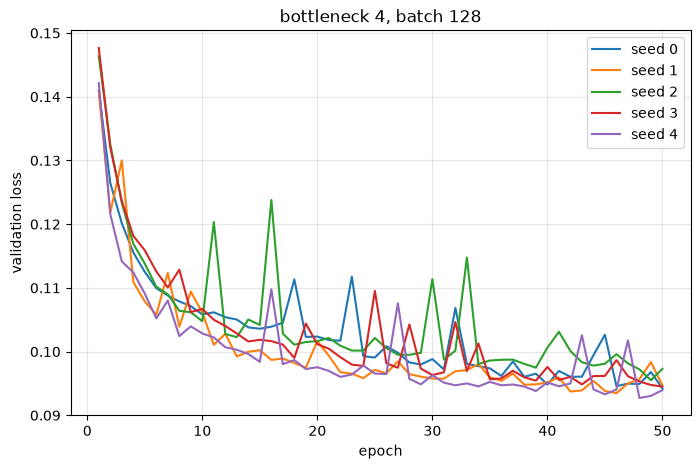

In [52]:
# validation curves
# create an empty graph that is 8 inches wide and 5 inches high.
plt.figure(figsize=(8, 5))

# draw one validation-loss line for each trained model.
for note in model_notes:
    # get all validation-loss values recorded for this model.
    curve = note["val_curve"]
    # create epoch numbers starting from 1.
    epoch_numbers = range(1, len(curve) + 1)

    # plot this model's validation loss against its epoch numbers.
    plt.plot(epoch_numbers, curve, label="seed " + str(note["seed"]))

# name the horizontal and vertical axes.
plt.xlabel("epoch")
plt.ylabel("validation loss")

# show the current bottleneck and batch size in the graph title.
plt.title("bottleneck " + str(bottleneck) + ", batch " + str(batch))
# show which graph line belongs to each seed.
plt.legend()
# add a light background grid to make values easier to read.
plt.grid(alpha=0.3)
# save the completed graph inside this configuration's results folder.
plt.savefig(folder + r"\val_curves.png", dpi=150, bbox_inches="tight")
# display the graph in the notebook.
plt.show()

change_weight    table: 0.6783   curve: 0.6783
drop_object      table: 0.7844   curve: 0.7844
force_stop       table: 0.7016   curve: 0.7016
long_wait        table: 0.8841   curve: 0.8839
outside_box      table: 0.7792   curve: 0.7792
push             table: 0.7832   curve: 0.7832
scale_speed      table: 0.8078   curve: 0.8078
tcp_wrench       table: 0.91   curve: 0.9098


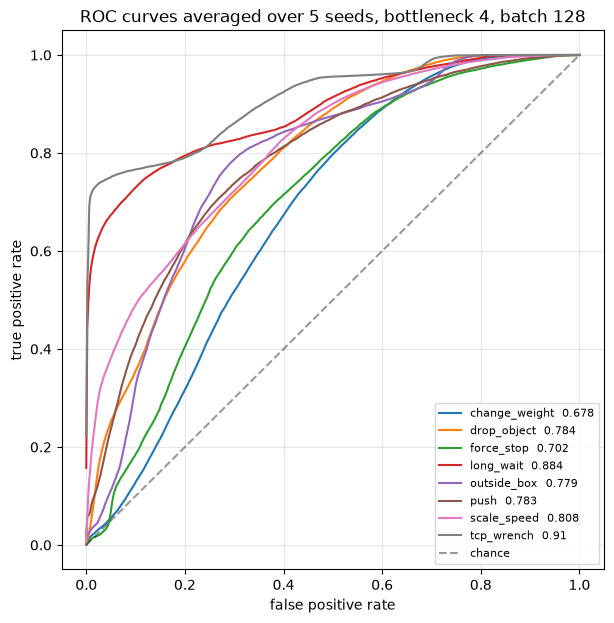

In [53]:
# ROC curves
#  One curve per fault averaged across all five seeds.
# Each seed produces its own curve, they are read off at the same shared positions, and then averaged.
# This is vertical averaging, the standard way of averaging ROC curves. The area under
# the averaged curve equals the average of the five areas.

# 500 evenly spaced false positive rates from 0 to 1
common_fpr = np.linspace(0, 1, 500)

# creae an empty square graph
plt.figure(figsize=(7, 7))


# draw one averaged ROC curve for each anomaly type.
for fault in fault_names:

    # select only test rows belonging to the current fault.
    belongs = (test_types == fault)

    # store this fault's ROC curve from each of the five models. 
    curves = []

    # process the anomaly scores from each seed/model.
    for errors in model_errors:

        # alculate this model's ROC curve for the current fault.
        false_positive_rate, true_positive_rate, thresholds = roc_curve(test_labels[belongs], errors[belongs])

        # read this seed's curve off at the 500 shared positions, so all five
        # curves have their points in the same places and can be averaged
        curves.append(np.interp(common_fpr, false_positive_rate, true_positive_rate))
    
    # convert the five stored curves into a NumPy array.
    # its shape will be: 5 models × 500 curve positions.
    curves = np.array(curves)

    # average the five models at every curve position.
    # this leaves one mean ROC curve containing 500 points.
    mean_curve = curves.mean(axis=0)

    # the same averaged score already in the results table
    score = results[results["anomaly_type"] == fault]["roc_auc"].mean()

    # checking the area under the averaged curve must equal the averaged score from
    # the table. Vertical averaging has this property.
    area = np.trapezoid(mean_curve, common_fpr)
    print(fault.ljust(16), "table:", round(score, 4), "  curve:", round(area, 4))

    # draw this fault's averaged ROC curve.
    plt.plot(common_fpr, mean_curve, label=fault + "  " + str(round(score, 3)))

# draw the diagonal representing random performance.
plt.plot([0, 1], [0, 1], "k--", alpha=0.4, label="chance")

# Add graph labels and formatting.
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.title("ROC curves averaged over 5 seeds, bottleneck " + str(bottleneck) + ", batch " + str(batch))
plt.legend(loc="lower right", fontsize=8)
plt.grid(alpha=0.3)

# saving
plt.savefig(folder + r"\roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()